## Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
 
warnings.filterwarnings('ignore')

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Fix random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load processed data
train_df = pd.read_csv('../data/processed/train.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

# Load scalers
with open('../models/scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open('../models/scaler_Y.pkl', 'rb') as f:
    scaler_Y = pickle.load(f)
with open('../models/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

# Load arrays
X_train_2d = np.load('../data/processed/X_train.npy')
X_test_2d  = np.load('../data/processed/X_test.npy')
y_train_2d = np.load('../data/processed/y_train.npy')
y_test_2d  = np.load('../data/processed/y_test.npy')

print(f"TensorFlow version: {tf.__version__}")
print(f"Data loaded successfully!")
print(f"X_train: {X_train_2d.shape} | X_test: {X_test_2d.shape}")
print(f"Features: {len(feature_cols)}")

TensorFlow version: 2.21.0
Data loaded successfully!
X_train: (14981, 43) | X_test: (3746, 43)
Features: 43


 ## Create sliding window sequences:

In [2]:
def create_sequences(X, y, window_size=12):
    """
    Convert 2D arrays into 3D sequences for LSTM.
    window_size=12 means 12 x 10min = 2 hours of history
    Input shape:  (samples, features)
    Output shape: (samples, window_size, features)
    """
    Xs, ys = [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i - window_size:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

WINDOW_SIZE = 12  # 2 hours of history → predict next 10 minutes

X_train_seq, y_train_seq = create_sequences(X_train_2d, y_train_2d, WINDOW_SIZE)
X_test_seq,  y_test_seq  = create_sequences(X_test_2d,  y_test_2d,  WINDOW_SIZE)

print(f"Sequence shapes:")
print(f"  X_train_seq: {X_train_seq.shape}  → (samples, window, features)")
print(f"  X_test_seq:  {X_test_seq.shape}")
print(f"  y_train_seq: {y_train_seq.shape}")
print(f"  y_test_seq:  {y_test_seq.shape}")
print(f"\nWindow size: {WINDOW_SIZE} steps = {WINDOW_SIZE * 10} minutes of history")

Sequence shapes:
  X_train_seq: (14969, 12, 43)  → (samples, window, features)
  X_test_seq:  (3734, 12, 43)
  y_train_seq: (14969, 1)
  y_test_seq:  (3734, 1)

Window size: 12 steps = 120 minutes of history


## Build LSTM architecture

In [3]:
n_features = X_train_seq.shape[2]

model = Sequential([
    # First LSTM layer — learns broad temporal patterns
    LSTM(128, return_sequences=True,
         input_shape=(WINDOW_SIZE, n_features)),
    BatchNormalization(),
    Dropout(0.2),

    # Second LSTM layer — learns finer patterns
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),

    # Dense layers — map LSTM output to prediction
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)  # Single output — energy consumption (Wh)
])

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'mse',
    metrics   = ['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        88,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,353 (548.25 KB)

 Trainable params: 139,969 (546.75 KB)

 Non-trainable params: 384 (1.50 KB)

## Define callbacks:

In [4]:
callbacks = [
    # Stop training when val_loss stops improving
    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 8,
        restore_best_weights = True,
        verbose   = 1
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 4,
        min_lr   = 1e-6,
        verbose  = 1
    ),

    # Save best model automatically
    ModelCheckpoint(
        filepath          = '../models/lstm_best.keras',
        monitor           = 'val_loss',
        save_best_only    = True,
        verbose           = 1
    )
]

print("Callbacks defined:")
print("  EarlyStopping    — patience=8, restores best weights")
print("  ReduceLROnPlateau — reduces LR by 0.5x if stuck for 4 epochs")
print("  ModelCheckpoint  — saves best model to models/lstm_best.keras")

Callbacks defined:
  EarlyStopping    — patience=8, restores best weights
  ReduceLROnPlateau — reduces LR by 0.5x if stuck for 4 epochs
  ModelCheckpoint  — saves best model to models/lstm_best.keras


## Train LSTM:

In [5]:
print("Training LSTM model...")
print("(EarlyStopping will stop automatically when val_loss stops improving)\n")

history = model.fit(
    X_train_seq, y_train_seq,
    epochs          = 60,
    batch_size      = 64,
    validation_split= 0.15,
    callbacks       = callbacks,
    shuffle         = False,  # CRITICAL — never shuffle time-series!
    verbose         = 1
)

print(f"\nTraining complete!")
print(f"Total epochs run: {len(history.history['loss'])}")
print(f"Best val_loss:    {min(history.history['val_loss']):.6f}")

Training LSTM model...
(EarlyStopping will stop automatically when val_loss stops improving)

Epoch 1/60
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4969 - mae: 0.5334
Epoch 1: val_loss improved from None to 0.13752, saving model to ../models/lstm_best.keras
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.3023 - mae: 0.4100 - val_loss: 0.1375 - val_mae: 0.2798 - learning_rate: 0.0010
Epoch 2/60
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1325 - mae: 0.2794
Epoch 2: val_loss improved from 0.13752 to 0.07040, saving model to ../models/lstm_best.keras
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1134 - mae: 0.2581 - val_loss: 0.0704 - val_mae: 0.1916 - learning_rate: 0.0010
Epoch 3/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0905 - mae: 0.2293
Epoch 3: val_loss improved from 0.07040 to 0.06262, saving model to ../models/lstm_best.keras
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0811 - mae: 0.2164 - val_loss: 0.0626 - val_mae: 0.1924 - learnin

## Plot training history

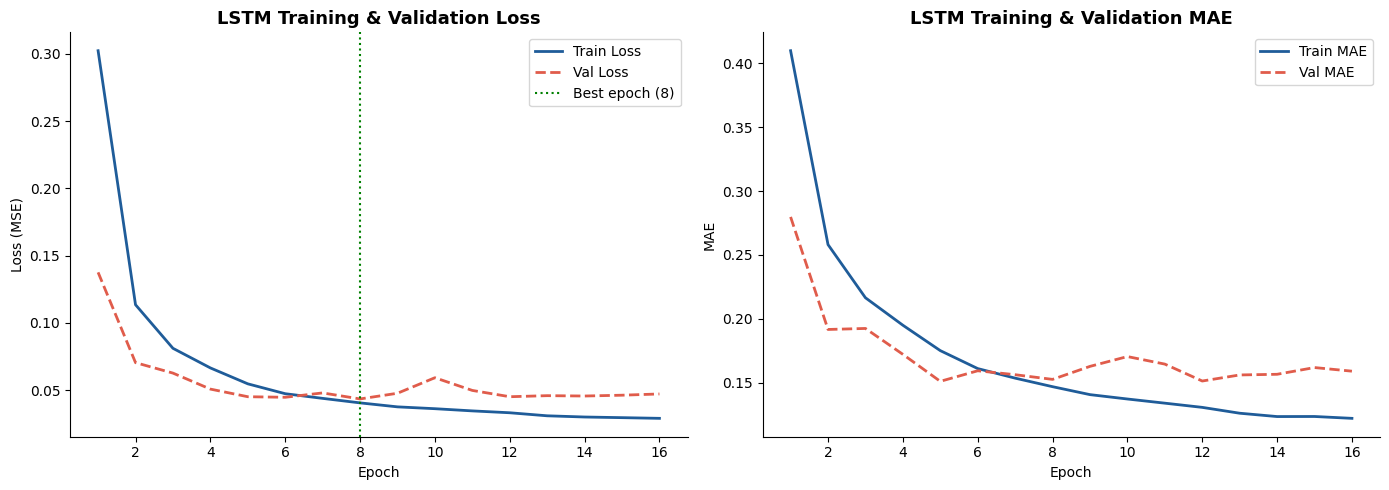

Best epoch: 8 / 16
Final train loss: 0.028989
Final val loss:   0.047114


In [6]:
epochs_run = len(history.history['loss'])
epoch_range = range(1, epochs_run + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epoch_range, history.history['loss'],
             color='#1F5C99', linewidth=2, label='Train Loss')
axes[0].plot(epoch_range, history.history['val_loss'],
             color='#E05C4B', linewidth=2, label='Val Loss', linestyle='--')
axes[0].set_title('LSTM Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

# Mark best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
axes[0].axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
                label=f'Best epoch ({best_epoch})')
axes[0].legend()

# MAE curve
axes[1].plot(epoch_range, history.history['mae'],
             color='#1F5C99', linewidth=2, label='Train MAE')
axes[1].plot(epoch_range, history.history['val_mae'],
             color='#E05C4B', linewidth=2, label='Val MAE', linestyle='--')
axes[1].set_title('LSTM Training & Validation MAE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/18_lstm_training_history.png', bbox_inches='tight')
plt.show()

print(f"Best epoch: {best_epoch} / {epochs_run}")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val loss:   {history.history['val_loss'][-1]:.6f}")

##  Evaluate LSTM

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test set
y_pred_lstm_scaled = model.predict(X_test_seq, verbose=0)

# Inverse transform back to original units (Wh)
y_true_orig = scaler_Y.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()
y_pred_orig = scaler_Y.inverse_transform(y_pred_lstm_scaled).ravel()

# Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
lstm_mae  = mean_absolute_error(y_true_orig, y_pred_orig)

print("="*45)
print("  LSTM — Evaluation Results")
print("="*45)
print(f"  RMSE : {lstm_rmse:.2f} Wh")
print(f"  MAE  : {lstm_mae:.2f} Wh")

  LSTM — Evaluation Results
  RMSE : 32.80 Wh
  MAE  : 22.46 Wh


 ## Actual vs Predicted plot

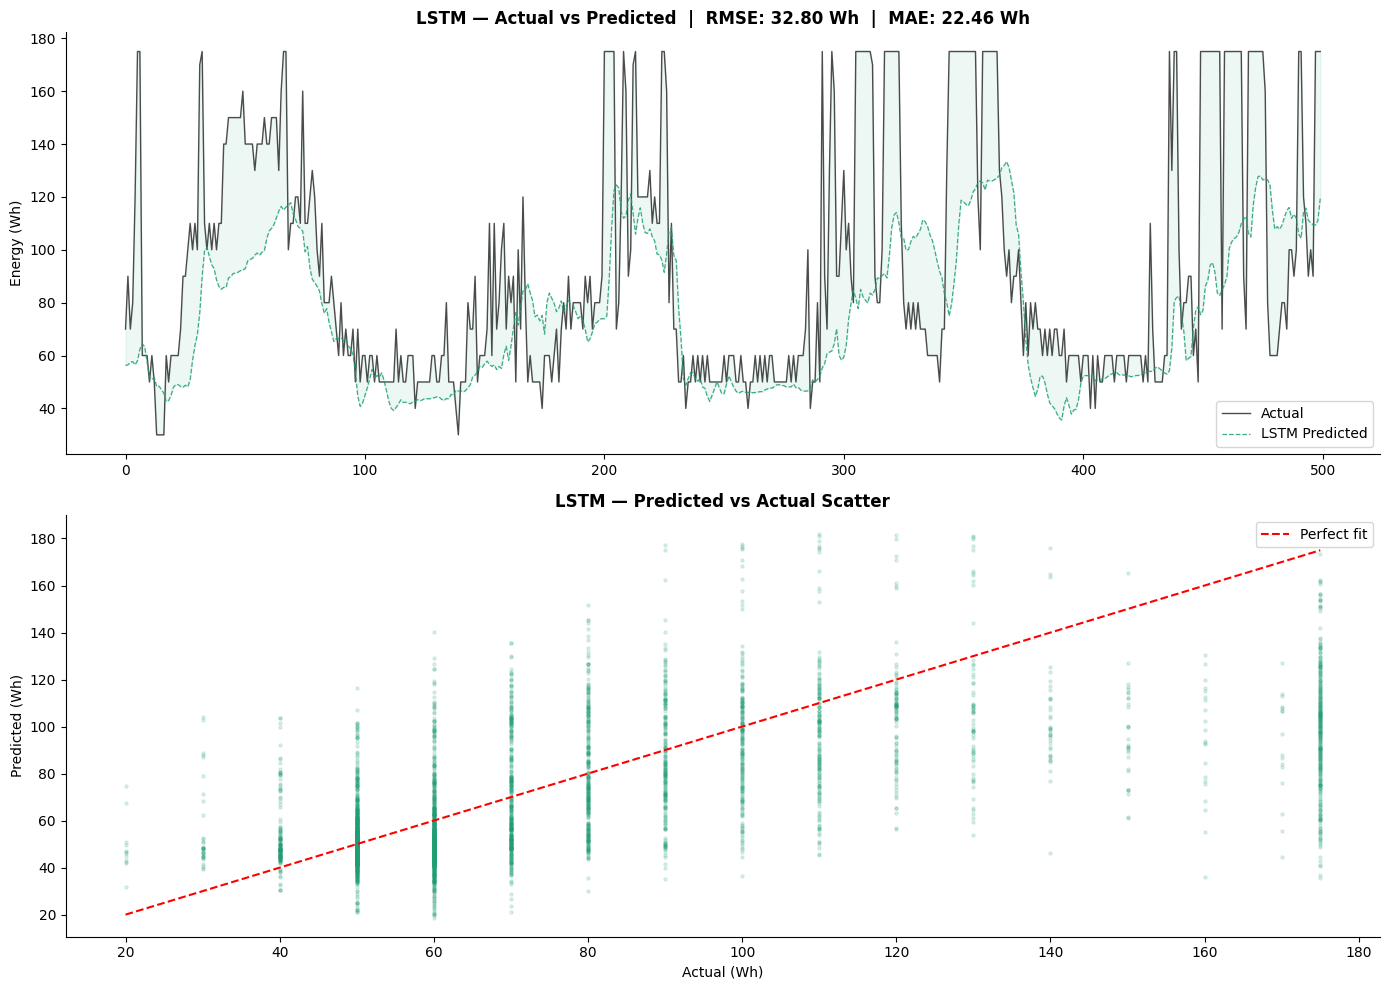

In [8]:
n = 500  # Plot last 500 test points for clarity

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full prediction overlay
axes[0].plot(range(n), y_true_orig[-n:],
             color='#2E2E2E', linewidth=1, label='Actual', alpha=0.85)
axes[0].plot(range(n), y_pred_orig[-n:],
             color='#1D9E75', linewidth=0.9, label='LSTM Predicted',
             linestyle='--', alpha=0.85)
axes[0].fill_between(range(n),
                     y_true_orig[-n:], y_pred_orig[-n:],
                     alpha=0.08, color='#1D9E75')
axes[0].set_title(
    f'LSTM — Actual vs Predicted  |  RMSE: {lstm_rmse:.2f} Wh  |  MAE: {lstm_mae:.2f} Wh',
    fontsize=12, fontweight='bold')
axes[0].set_ylabel('Energy (Wh)')
axes[0].legend()

# Scatter: predicted vs actual
axes[1].scatter(y_true_orig, y_pred_orig,
                alpha=0.15, s=5, color='#1D9E75')
axes[1].plot([y_true_orig.min(), y_true_orig.max()],
             [y_true_orig.min(), y_true_orig.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_title('LSTM — Predicted vs Actual Scatter', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual (Wh)')
axes[1].set_ylabel('Predicted (Wh)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/19_lstm_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

 ## Residual analysis

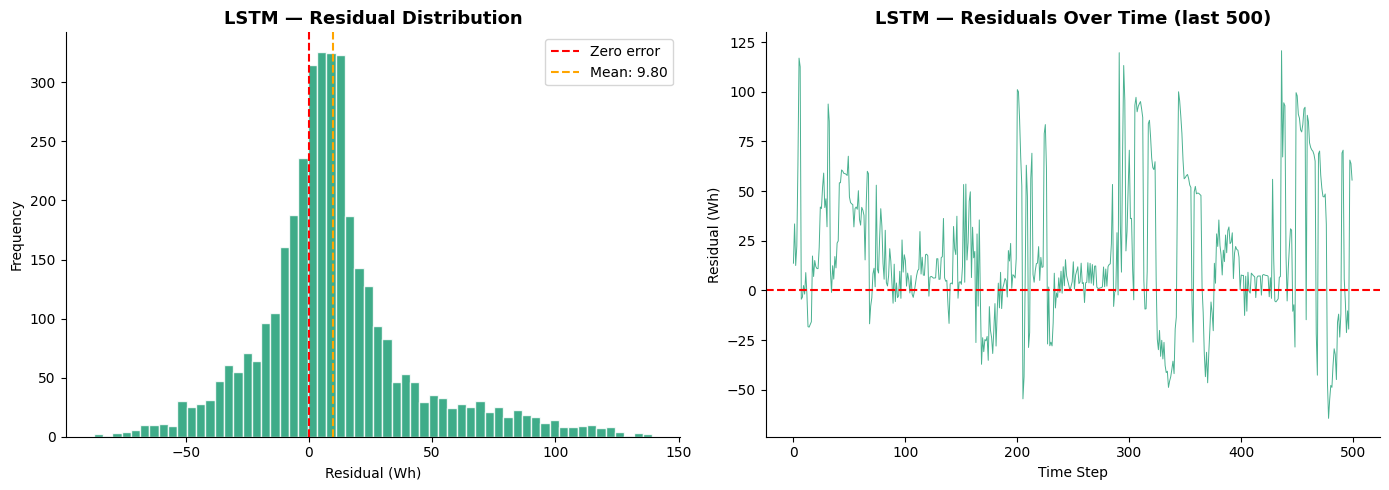

Residual stats:
  Mean:  9.80 Wh  (closer to 0 = better)
  Std:   31.30 Wh
  Max:   139.28 Wh
  Min:   -87.38 Wh


In [11]:
residuals = y_true_orig - y_pred_orig

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=60, color='#1D9E75', alpha=0.85, edgecolor='white')
axes[0].axvline(0,                color='red',    linestyle='--', linewidth=1.5, label='Zero error')
axes[0].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: {residuals.mean():.2f}')
axes[0].set_title('LSTM — Residual Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (Wh)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Residuals over time
axes[1].plot(range(len(residuals[-500:])), residuals[-500:],
             color='#1D9E75', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('LSTM — Residuals Over Time (last 500)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Residual (Wh)')

plt.tight_layout()
plt.savefig('../outputs/figures/20_lstm_residuals.png', bbox_inches='tight')
plt.show()

print(f"Residual stats:")
print(f"  Mean:  {residuals.mean():.2f} Wh  (closer to 0 = better)")
print(f"  Std:   {residuals.std():.2f} Wh")
print(f"  Max:   {residuals.max():.2f} Wh")
print(f"  Min:   {residuals.min():.2f} Wh")

## Save results & update comparison:

In [12]:
# Load existing results from Phase 5
with open('../outputs/results.json', 'r') as f:
    results = json.load(f)

# Add LSTM results
results['LSTM'] = {
    'RMSE': round(lstm_rmse, 2),
    'MAE' : round(lstm_mae,  2)
}

# Save updated results
with open('../outputs/results.json', 'w') as f:
    json.dump(results, f, indent=4)

# Save LSTM model
model.save('../models/lstm_model.keras')

# Save sequence window size for Streamlit app
with open('../models/lstm_config.pkl', 'wb') as f:
    pickle.dump({'window_size': WINDOW_SIZE, 'n_features': n_features}, f)

# Print final comparison table
print("="*50)
print("  Full Model Comparison (all 3 models)")
print("="*50)
print(f"  {'Model':<22} {'RMSE (Wh)':>10} {'MAE (Wh)':>10}")
print(f"  {'-'*44}")
for model_name, metrics in results.items():
    print(f"  {model_name:<22} {metrics['RMSE']:>10.2f} {metrics['MAE']:>10.2f}")

best_model = min(results, key=lambda x: results[x]['RMSE'])
print(f"\n  Best model by RMSE: {best_model} ")

print("\nSaved:")
print("  models/lstm_model.keras")
print("  models/lstm_best.keras")
print("  models/lstm_config.pkl")
print("  outputs/results.json   (updated with LSTM)")
print("\nPhase 6 complete! Move on to 07_comparison.ipynb ")

  Full Model Comparison (all 3 models)
  Model                   RMSE (Wh)   MAE (Wh)
  --------------------------------------------
  Ridge Regression            21.35      14.43
  Random Forest               24.16      18.75
  LSTM                        32.80      22.46

  Best model by RMSE: Ridge Regression 

Saved:
  models/lstm_model.keras
  models/lstm_best.keras
  models/lstm_config.pkl
  outputs/results.json   (updated with LSTM)

Phase 6 complete! Move on to 07_comparison.ipynb 
